In [1]:
import os
import numpy as np
import keras.applications as ka
import keras
import tensorflow as tf
from tensorflow.keras.preprocessing.image import img_to_array, load_img
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.optimizers import SGD
import matplotlib.pyplot as plt
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix as sk_confusion_matrix
import seaborn as sns

2025-04-12 17:53:58.616949: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-12 17:53:58.642872: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-04-12 17:53:58.642903: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-04-12 17:53:58.643574: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-12 17:53:58.648625: I tensorflow/core/platform/cpu_feature_guar

In [ ]:
def my_team():
    '''
    Return the list of the team members of this assignment submission as a list
    of triplet of the form (student_number, first_name, last_name)
    
    '''
    return [(11427591, 'Mohan', 'Hao')]

In [3]:
def load_model():
    base_model = tf.keras.applications.MobileNetV2(weights='imagenet', include_top=False)
    base_model.trainable = False  # Freeze the layers
    return base_model

def load_data(path):
    labels = []
    images = []
    class_names = [] 
    classes = {'daisy': 0, 'dandelion': 1, 'roses': 2, 'sunflowers': 3, 'tulips': 4}
    for label, encoding in classes.items():
        class_dir = os.path.join(path, label)
        class_names.append(label)
        for file in os.listdir(class_dir):
            img_path = os.path.join(class_dir, file)
            img = load_img(img_path, target_size=(224, 224))
            images.append(img_to_array(img))
            labels.append(encoding)
    images = (np.array(images, dtype='float32') / 127.5) - 1  # Normalize to [-1, 1]
    labels = np.array(labels)
    labels = to_categorical(labels, num_classes=5)  # One-hot encode labels
    return images, labels, class_names

def split_data(X, Y, train_fraction, randomize=False, eval_set=True):
    # Convert one-hot encoded labels back to single labels for stratification
    labels = np.argmax(Y, axis=1)
    unique_classes = np.unique(labels)
    class_indices = {cls: np.where(labels == cls)[0] for cls in unique_classes}
    train_indices = []
    test_indices = []
    eval_indices = []
    for cls, indices in class_indices.items():
        if randomize:
            np.random.shuffle(indices)
        num_train = int(len(indices) * train_fraction)
        num_test = len(indices) - num_train
        num_eval = 0
        if eval_set:
            num_eval = num_test // 2
            num_test -= num_eval
        train_indices.extend(indices[:num_train])
        test_indices.extend(indices[num_train:num_train + num_test])
        if eval_set:
            eval_indices.extend(indices[num_train + num_test:])
    X_train, Y_train = X[train_indices], Y[train_indices]
    X_test, Y_test = X[test_indices], Y[test_indices]
    if eval_set:
        X_eval, Y_eval = X[eval_indices], Y[eval_indices]
        return (X_train, Y_train), (X_test, Y_test), (X_eval, Y_eval)
    else:
        return (X_train, Y_train), (X_test, Y_test)

In [4]:
def confusion_matrix(test_labels, predictions, class_names, accuracy=None, plot=False):
    # Ensure labels are 1D
    if test_labels.ndim > 1:
        test_labels = np.argmax(test_labels, axis=1)

    # Number of classes
    num_classes = len(class_names)

    # Initialize the confusion matrix
    cm = np.zeros((num_classes, num_classes), dtype=int)

    # Populate the confusion matrix
    for true_label, pred_label in zip(test_labels, predictions):
        cm[true_label, pred_label] += 1

    # Normalize the confusion matrix
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    # Plot the confusion matrix if required
    if plot:
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap='Blues', xticklabels=class_names, yticklabels=class_names)
        title = 'Normalized Confusion Matrix'
        if accuracy is not None:
            title += f' (Accuracy: {accuracy:.2f})'
        plt.title(title)
        plt.xlabel('Predicted label')
        plt.ylabel('True label')
        plt.show()

    return cm

def precision(predictions, true_labels, class_names):
    precision_scores = np.zeros(len(class_names))
    for i, class_name in enumerate(class_names):
        tp = np.sum((predictions == i) & (true_labels == i))
        fp = np.sum((predictions == i) & (true_labels != i))
        precision_scores[i] = tp / (tp + fp) if (tp + fp) > 0 else 0
    return precision_scores

def recall(predictions, true_labels, class_names):
    recall_scores = np.zeros(len(class_names))
    for i, class_name in enumerate(class_names):
        tp = np.sum((predictions == i) & (true_labels == i))
        fn = np.sum((predictions != i) & (true_labels == i))
        recall_scores[i] = tp / (tp + fn) if (tp + fn) > 0 else 0
    return recall_scores

def f1(predictions, true_labels, class_names):
    prec = precision(predictions, true_labels, class_names)
    rec = recall(predictions, true_labels, class_names)
    f1 = 2 * (prec * rec) / (prec + rec)
    f1 = np.nan_to_num(f1)  # Handles division by zero in case of zero precision and recall
    return f1

def k_fold_validation(features, ground_truth, classifier_func, class_names, k=5):
    n = len(features)
    indices = np.arange(n)
    np.random.shuffle(indices)
    fold_size = n // k
    all_metrics = []
    for i in range(k):
        test_indices = indices[i * fold_size: (i + 1) * fold_size if i < k - 1 else n]
        train_indices = np.setdiff1d(indices, test_indices)
        train_features = features[train_indices]
        train_labels = ground_truth[train_indices]
        test_features = features[test_indices]
        test_labels = ground_truth[test_indices]
        metrics = classifier_func(train_features, train_labels, test_features, test_labels)
        all_metrics.append(metrics)
    all_metrics = np.array(all_metrics)  # Shape should be [k, 3] if metrics returned as [precision, recall, f1]
    avg_metrics = np.mean(all_metrics, axis=0)
    sigma_metrics = np.std(all_metrics, axis=0)
    return avg_metrics, sigma_metrics

In [5]:
def plot_training_history(history, title='Model Training', test_accuracy=None):
    acc = history.history.get('accuracy')
    val_acc = history.history.get('val_accuracy')
    loss = history.history.get('loss')
    val_loss = history.history.get('val_loss')
    epochs = range(1, len(acc) + 1)

    # Set the title with test accuracy if provided
    if test_accuracy is not None:
        title += f' (Test Acc: {test_accuracy:.2f})'

    plt.figure(figsize=(14, 6))

    plt.subplot(1, 3, 1)
    plt.plot(epochs, acc, label='Training acc')
    plt.title(f'{title} - Training Accuracy')
    plt.legend()

    plt.subplot(1, 3, 2)
    if val_acc:
        plt.plot(epochs, val_acc, label='Validation acc')
    plt.title(f'{title} - Validation Accuracy')
    plt.legend()

    plt.subplot(1, 3, 3)
    plt.plot(epochs, loss, label='Training loss')
    if val_loss:
        plt.plot(epochs, val_loss, label='Validation loss')
    plt.title(f'{title} - Training and Validation Loss')
    plt.legend()

    plt.show()

In [6]:
def transfer_learning(train_set, eval_set, test_set, base_model, parameters, class_names):
    learning_rate, momentum, nesterov = parameters
    x = GlobalAveragePooling2D()(base_model.output)
    x = Dense(1024, activation='relu')(x)
    predictions = Dense(len(class_names), activation='softmax')(x)
    new_model = Model(inputs=base_model.input, outputs=predictions)
    optimizer = SGD(learning_rate=learning_rate, momentum=momentum, nesterov=nesterov)
    new_model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

    # Capture the training history
    if eval_set is not None:
        history = new_model.fit(train_set[0], train_set[1], validation_data=eval_set, epochs=10)
    else:
        history = new_model.fit(train_set[0], train_set[1], epochs=10)

    loss, accuracy = new_model.evaluate(test_set[0], test_set[1])
    predictions = new_model.predict(test_set[0])
    predicted_classes = np.argmax(predictions, axis=1)
    actual_classes = np.argmax(test_set[1], axis=1)
    precision_scores = precision(predicted_classes, actual_classes, class_names)
    recall_scores = recall(predicted_classes, actual_classes, class_names)
    f1_scores = f1(predicted_classes, actual_classes, class_names)
    metrics = [precision_scores, recall_scores, f1_scores]

    new_model.save("trained_model_transfer.h5")

    # Plot the training history with test accuracy
    plot_training_history(history, title='Transfer Learning Model Training', test_accuracy=accuracy)

    # Plot confusion matrix with test accuracy
    confusion_matrix(actual_classes, predicted_classes, class_names, accuracy=accuracy, plot=False)

    return new_model, metrics

def accelerated_learning(train_set, eval_set, test_set, base_model, parameters, class_names):
    train_features = base_model.predict(train_set[0])
    if eval_set is not None:
        eval_features = base_model.predict(eval_set[0])
    else:
        eval_features = None
    if test_set is not None:
        test_features = base_model.predict(test_set[0])
        test_labels = test_set[1]
    else:
        return None, "No test set provided"

    top_model = Sequential([
        GlobalAveragePooling2D(input_shape=train_features.shape[1:]),
        Dense(1024, activation='relu'),
        Dense(len(class_names), activation='softmax')
    ])
    learning_rate, momentum, nesterov = parameters
    optimizer = SGD(learning_rate=learning_rate, momentum=momentum, nesterov=nesterov)
    top_model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

    # Capture the training history
    if eval_features is not None:
        history = top_model.fit(train_features, train_set[1], validation_data=(eval_features, eval_set[1]), epochs=10)
    else:
        history = top_model.fit(train_features, train_set[1], epochs=10)

    loss, accuracy = top_model.evaluate(test_features, test_labels)
    predictions = top_model.predict(test_features)
    predicted_classes = np.argmax(predictions, axis=1)
    actual_classes = np.argmax(test_labels, axis=1)
    precision_scores = precision(predicted_classes, actual_classes, class_names)
    recall_scores = recall(predicted_classes, actual_classes, class_names)
    f1_scores = f1(predicted_classes, actual_classes, class_names)
    metrics = [precision_scores, recall_scores, f1_scores]

    top_model.save("trained_model_accelerated.h5")

    # Plot the training history with test accuracy
    plot_training_history(history, title='Accelerated Learning Model Training', test_accuracy=accuracy)

    # Plot confusion matrix with test accuracy
    confusion_matrix(actual_classes, predicted_classes, class_names, accuracy=accuracy, plot=False)

    return top_model, metrics

In [7]:
def transfer_learning_classifier(train_features, train_labels, test_features, test_labels, base_model, parameters, class_names):
    _, metrics = transfer_learning((train_features, train_labels), None, (test_features, test_labels), base_model, parameters, class_names)
    return metrics

def accelerated_learning_classifier(train_features, train_labels, test_features, test_labels, base_model, parameters, class_names):
    _, metrics = accelerated_learning((train_features, train_labels), None, (test_features, test_labels), base_model, parameters, class_names)
    return metrics

In [8]:
def plot_confusion_matrix(cm, classes, title='Confusion Matrix', cmap=plt.cm.Blues):
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = 'd' if np.issubdtype(cm.dtype, np.integer) else '.2f'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

def plot_confusion_matrices(train_labels, train_predictions, test_labels, test_predictions, class_names, train_metrics, test_metrics):
    plt.figure(figsize=(14, 6))

    # Training set confusion matrix
    cm_train = confusion_matrix(train_labels, train_predictions, class_names)
    plt.subplot(1, 2, 1)
    plot_confusion_matrix(cm_train, classes=class_names, title=f'Training Confusion Matrix\nAccuracy: {train_metrics[1]:.2f}, F1: {train_metrics[2]:.2f}')

    # Testing set confusion matrix
    cm_test = confusion_matrix(test_labels, test_predictions, class_names)
    plt.subplot(1, 2, 2)
    plot_confusion_matrix(cm_test, classes=class_names, title=f'Testing Confusion Matrix\nAccuracy: {test_metrics[1]:.2f}, F1: {test_metrics[2]:.2f}')

    plt.show()

/tmp/ipykernel_321403/91447396.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(weights='imagenet', include_top=False)
2025-04-12 17:54:01.149913: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:02:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-04-12 17:54:01.261429: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:02:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-04-12 17:54:01.261483: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:02:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-04-1

Training class distribution:
daisy: 160.0
dandelion: 160.0
roses: 160.0
sunflowers: 160.0
tulips: 160.0
Testing class distribution:
daisy: 20.0
dandelion: 20.0
roses: 20.0
sunflowers: 20.0
tulips: 20.0
Validation class distribution:
daisy: 20.0
dandelion: 20.0
roses: 20.0
sunflowers: 20.0
tulips: 20.0
Epoch 1/10


2025-04-12 17:54:08.542878: I external/local_xla/xla/service/service.cc:168] XLA service 0x4987db20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-04-12 17:54:08.542922: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 3080 Ti, Compute Capability 8.6
2025-04-12 17:54:08.642740: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-04-12 17:54:09.010344: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8907
2025-04-12 17:54:09.259773: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory


 9/25 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.2025 - loss: 1.7091

I0000 00:00:1744444455.058089  321623 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


25/25 ━━━━━━━━━━━━━━━━━━━━ 17s 277ms/step - accuracy: 0.3240 - loss: 1.5406 - val_accuracy: 0.7400 - val_loss: 0.8622
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7621 - loss: 0.7380 - val_accuracy: 0.8000 - val_loss: 0.6145
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8661 - loss: 0.4780 - val_accuracy: 0.8000 - val_loss: 0.5457
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9160 - loss: 0.3739 - val_accuracy: 0.8200 - val_loss: 0.5082
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9160 - loss: 0.3367 - val_accuracy: 0.7800 - val_loss: 0.4957
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9286 - loss: 0.2772 - val_accuracy: 0.7800 - val_loss: 0.4928
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9246 - loss: 0.2784 - val_accuracy: 0.8000 - val_loss: 0.4773
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9489 - loss: 0.2334 - val_accuracy: 0.8000 - val_loss: 

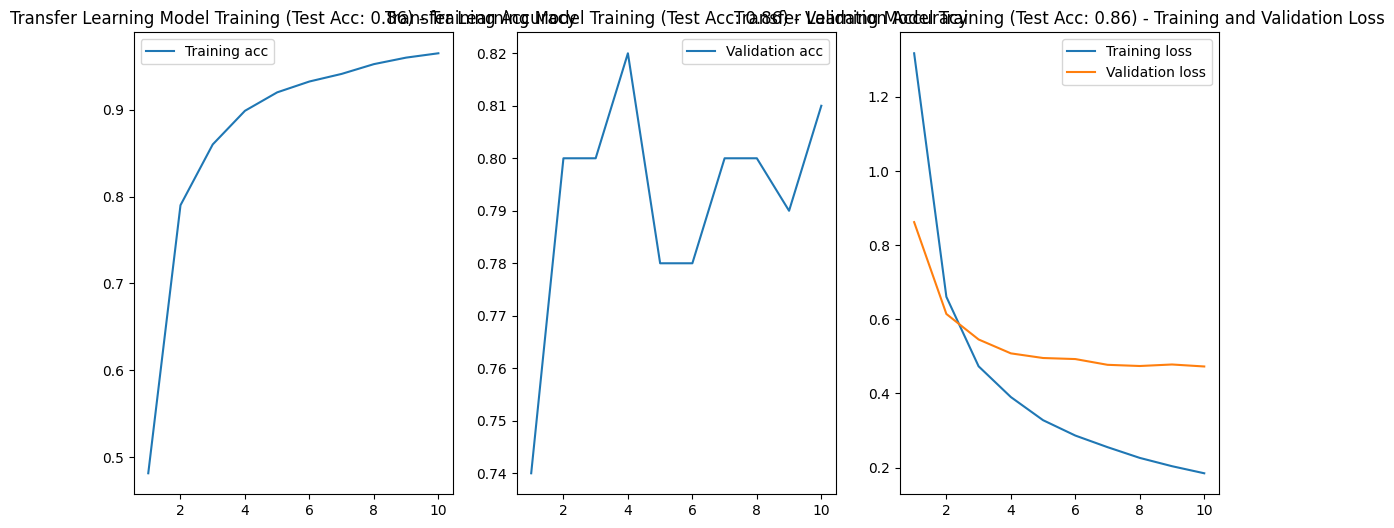

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, None,      │        864 │ input_layer[0][0] │
│                     │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, None,      │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, None,      │          0 │ bn_Conv1[0][0]    │
│                     │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, None,      │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, None,      │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, None,      │          0 │ expanded_conv_de… │
│ (ReLU)              │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, None,      │        512 │ expanded_conv_de… │
│ (Conv2D)            │ None, 16)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, None,      │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ None, 16)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, None,      │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, None,      │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, None,      │          0 │ block_1_expand_B… │
│ (ReLU)              │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, None,      │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, None,      │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, None,      │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, None,      │          0 │ block_1_depthwis… │
│ (ReLU)              │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, None,      │      2,304 │ block_1_depthwis

 Total params: 4,891,724 (18.66 MB)

 Trainable params: 1,316,869 (5.02 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 1,316,871 (5.02 MB)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Transfer Learning Model Performance: [array([0.9       , 1.        , 0.85      , 0.86363636, 0.72727273]), array([0.9 , 0.8 , 0.85, 0.95, 0.8 ]), array([0.9       , 0.88888889, 0.85      , 0.9047619 , 0.76190476])]


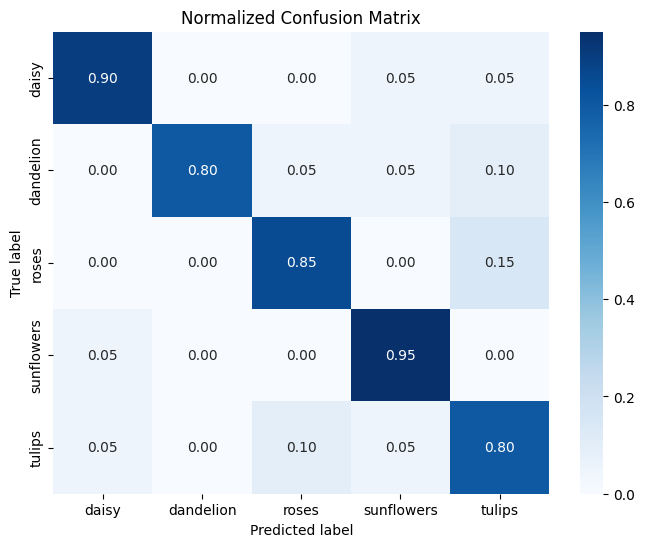

25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 635ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Epoch 1/10


/home/imhaom/.local/lib/python3.11/site-packages/keras/src/layers/pooling/base_global_pooling.py:12: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.3669 - loss: 1.5049 - val_accuracy: 0.7400 - val_loss: 0.8207
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7878 - loss: 0.7218 - val_accuracy: 0.8000 - val_loss: 0.5889
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8860 - loss: 0.4856 - val_accuracy: 0.8300 - val_loss: 0.5346
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8867 - loss: 0.4347 - val_accuracy: 0.8400 - val_loss: 0.4918
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9350 - loss: 0.3211 - val_accuracy: 0.8200 - val_loss: 0.4724
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9340 - loss: 0.2976 - val_accuracy: 0.8400 - val_loss: 0.4588
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9401 - loss: 0.2569 - val_accuracy: 0.8300 - val_loss: 0.4550
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9429 - loss: 0.2416 - val_accuracy: 0.8500 - val_loss: 0.4574
Ep

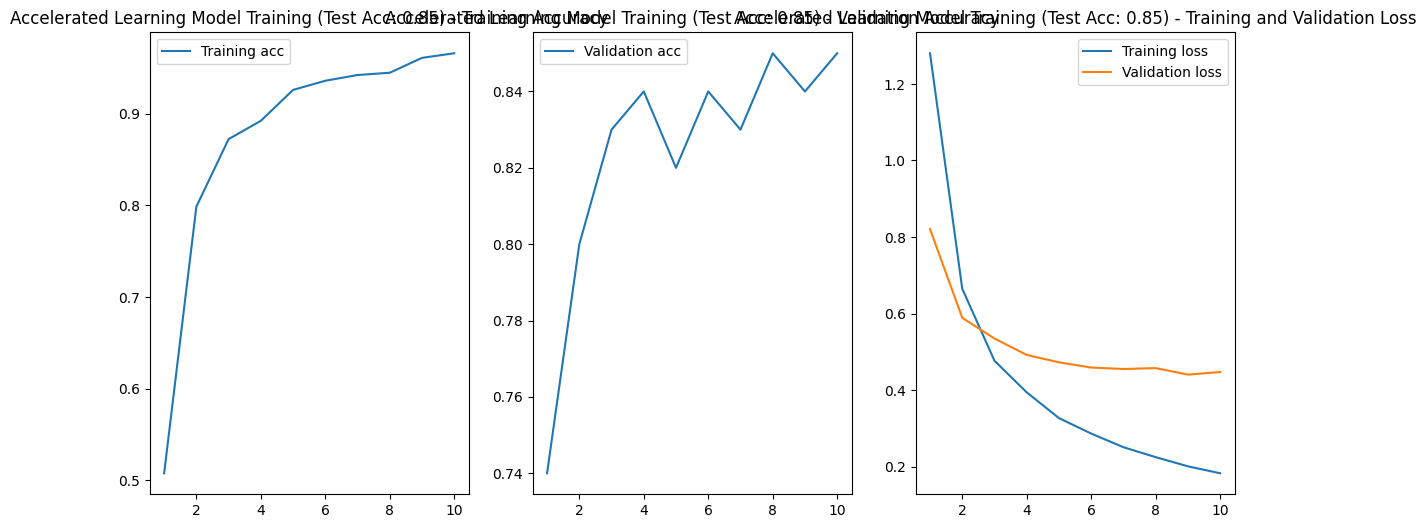

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1024)           │     1,311,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │         5,125 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,633,740 (10.05 MB)

 Trainable params: 1,316,869 (5.02 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,316,871 (5.02 MB)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Accelerated Learning Model Performance: [array([0.88235294, 0.94444444, 0.94117647, 0.79166667, 0.75      ]), array([0.75, 0.85, 0.8 , 0.95, 0.9 ]), array([0.81081081, 0.89473684, 0.86486486, 0.86363636, 0.81818182])]


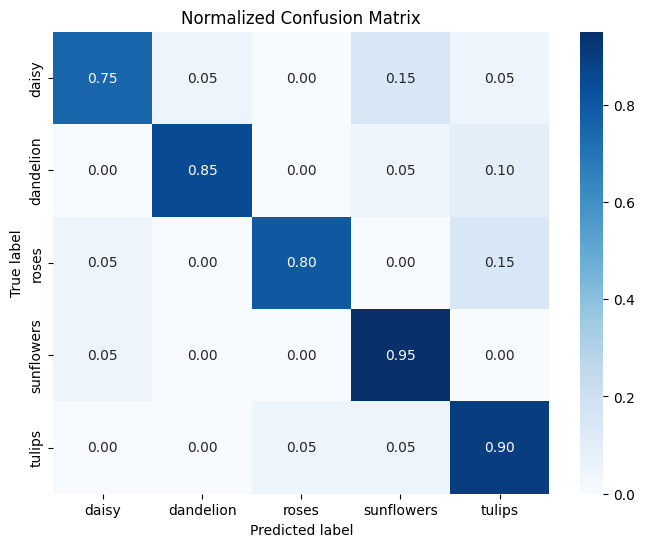

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.4037 - loss: 1.4397
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7649 - loss: 0.7694
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8386 - loss: 0.5189
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8830 - loss: 0.4111
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9146 - loss: 0.3390
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9189 - loss: 0.3024
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9483 - loss: 0.2514
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9373 - loss: 0.2353
Epoch 9/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9581 - loss: 0.2087
Epoch 10/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9609 - loss: 0.2056
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 762ms/step - accuracy: 0.8927 - loss: 0.3825
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 320ms/step


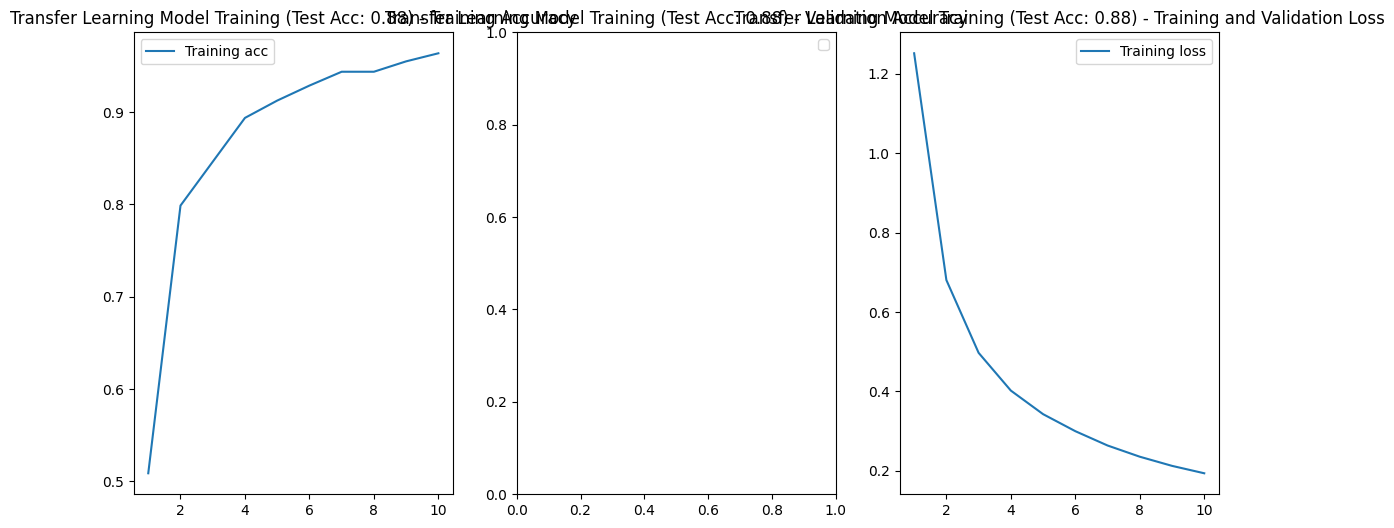

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.3398 - loss: 1.5922
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7946 - loss: 0.7395
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8514 - loss: 0.5068
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8781 - loss: 0.3994
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9154 - loss: 0.3274
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9241 - loss: 0.3013
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9523 - loss: 0.2521
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9488 - loss: 0.2376
Epoch 9/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9516 - loss: 0.2124
Epoch 10/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9636 - loss: 0.1882
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 158ms/step - accuracy: 0.8444 - loss: 0.4177
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 304ms/step


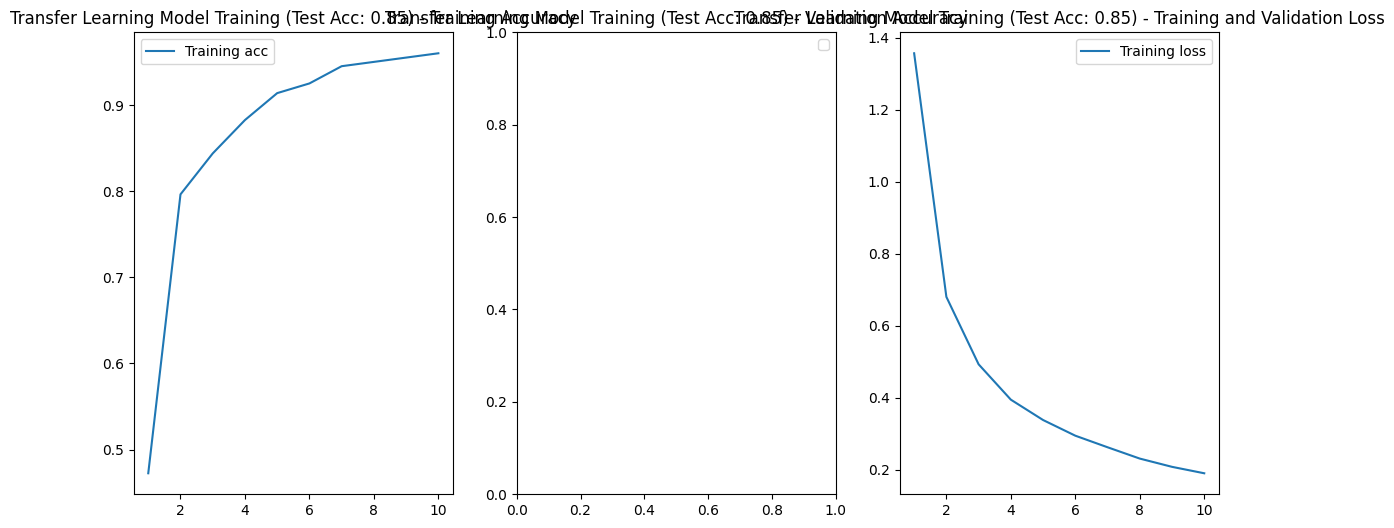

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.2900 - loss: 1.5727
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7288 - loss: 0.7939
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8349 - loss: 0.5564
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8860 - loss: 0.4507
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8998 - loss: 0.3596
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9194 - loss: 0.3295
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9447 - loss: 0.2759
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9507 - loss: 0.2562
Epoch 9/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9628 - loss: 0.2216
Epoch 10/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9655 - loss: 0.2080
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 152ms/step - accuracy: 0.8938 - loss: 0.3290


7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 306ms/step


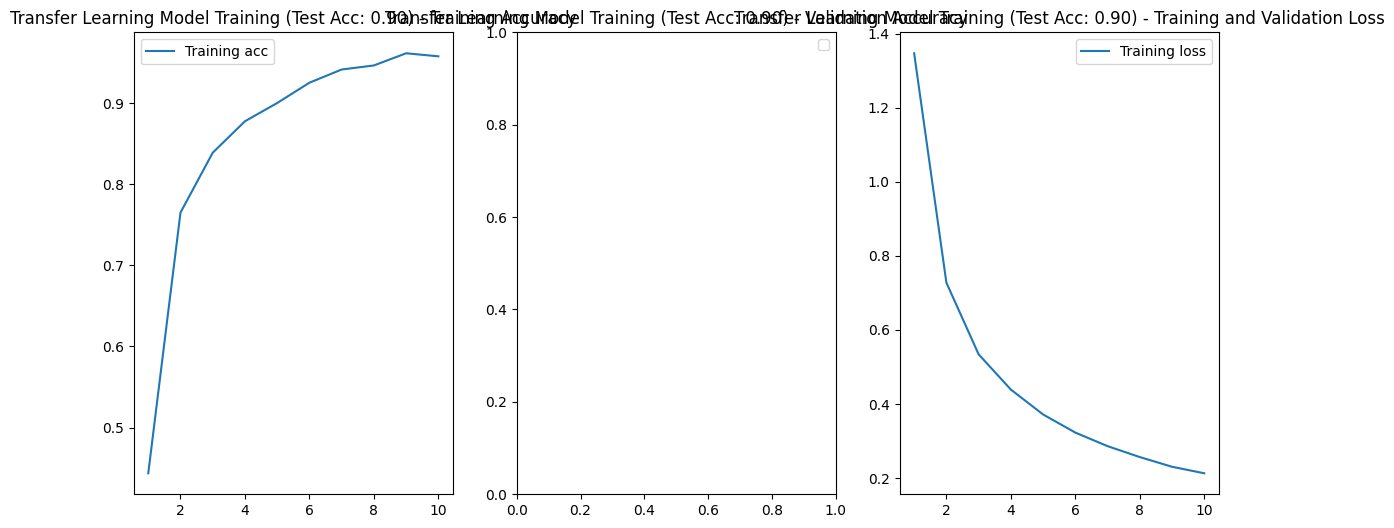

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.2853 - loss: 1.6084
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7663 - loss: 0.7606
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8564 - loss: 0.5001
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8869 - loss: 0.3987
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9130 - loss: 0.3262
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9407 - loss: 0.2942
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9320 - loss: 0.2795
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9589 - loss: 0.2140
Epoch 9/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9665 - loss: 0.1964
Epoch 10/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9617 - loss: 0.1824
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 151ms/step - accuracy: 0.8445 - loss: 0.4227


7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 312ms/step


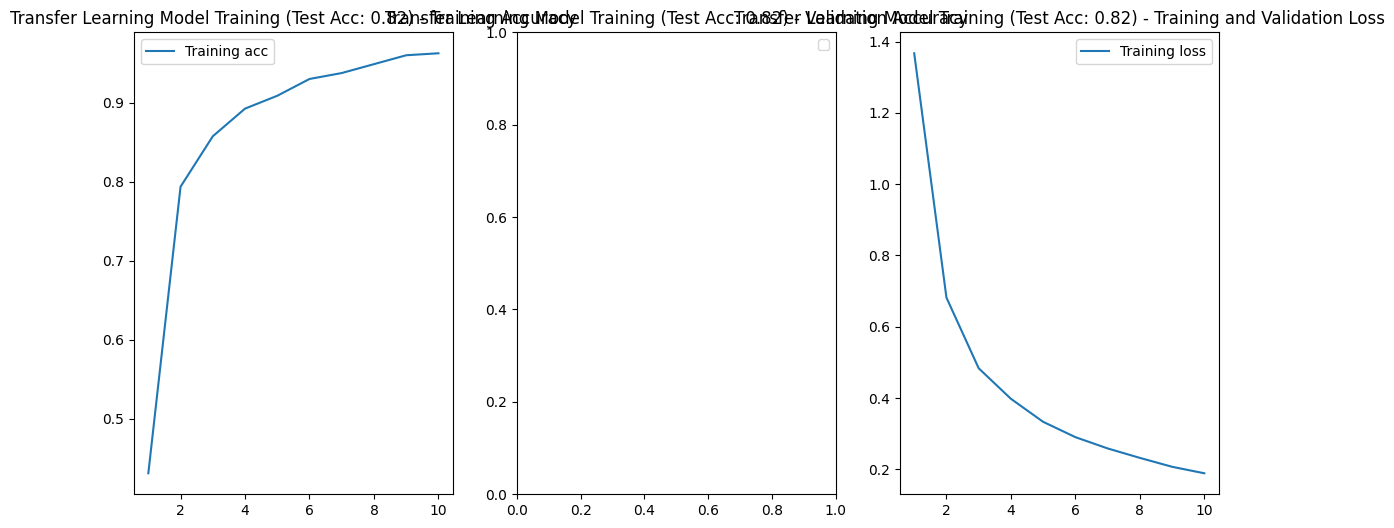

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.3007 - loss: 1.6170
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7799 - loss: 0.7309
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8796 - loss: 0.4903
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9048 - loss: 0.4017
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9290 - loss: 0.3297
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9336 - loss: 0.3047
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9340 - loss: 0.2777
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9496 - loss: 0.2558
Epoch 9/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9533 - loss: 0.2182
Epoch 10/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9626 - loss: 0.2014
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 153ms/step - accuracy: 0.8578 - loss: 0.4139
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 370ms/step


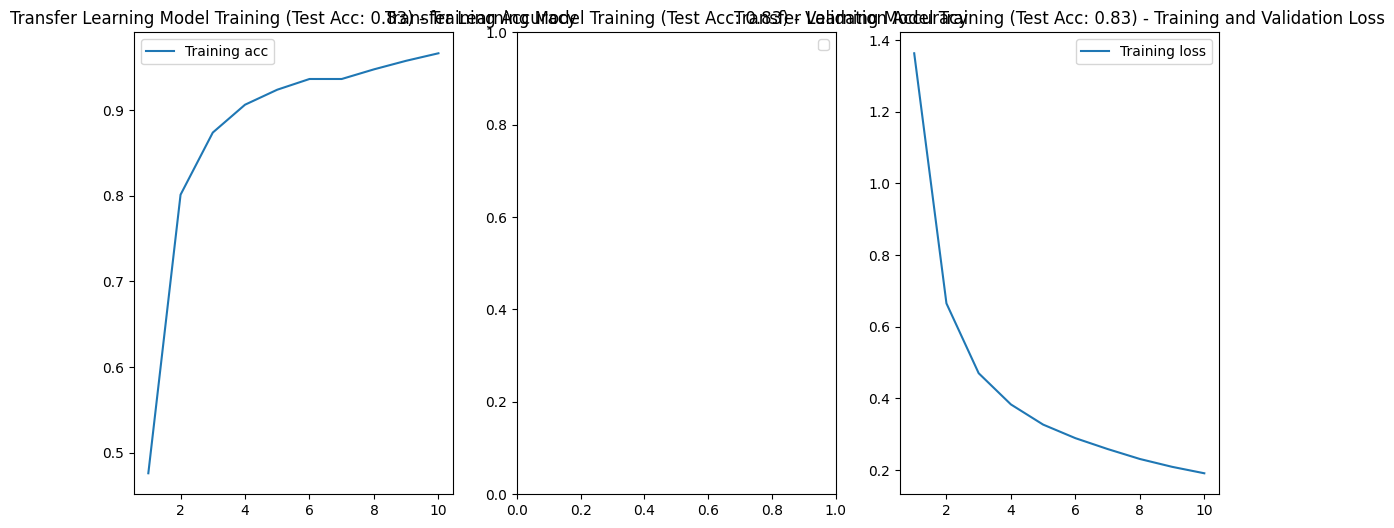

Transfer Learning - Avg Metrics:
 [[0.89772061 0.90794486 0.81760856 0.8452498  0.83326517]
 [0.87232875 0.89027861 0.86064058 0.88543062 0.78594577]
 [0.88342068 0.89780027 0.83754243 0.8639917  0.80412471]]
Transfer Learning - Sigma Metrics:
 [[0.06418629 0.04721357 0.03683425 0.0598737  0.06717262]
 [0.05586956 0.05752782 0.06148351 0.04521179 0.06304137]
 [0.04907796 0.04059234 0.04084742 0.04593617 0.02317853]]
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 155ms/step
Epoch 1/10


/home/imhaom/.local/lib/python3.11/site-packages/keras/src/layers/pooling/base_global_pooling.py:12: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3609 - loss: 1.4632 
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8037 - loss: 0.7032
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8722 - loss: 0.4755
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8811 - loss: 0.4049
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9130 - loss: 0.3266
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9381 - loss: 0.2720
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9578 - loss: 0.2355
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9589 - loss: 0.2231
Epoch 9/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9632 - loss: 0.2092
Epoch 10/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9703 - loss: 0.1890
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8611 - loss: 0.4818
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


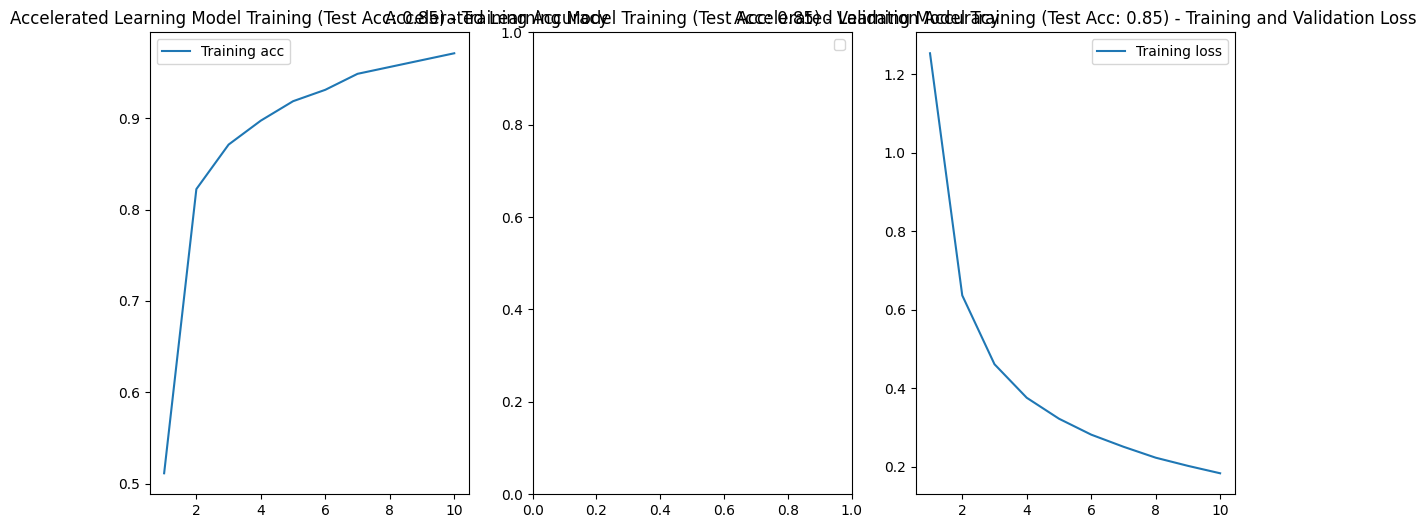

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3473 - loss: 1.5732 
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7539 - loss: 0.7647
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8647 - loss: 0.4932
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8679 - loss: 0.4218
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9056 - loss: 0.3671
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9458 - loss: 0.2943
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9324 - loss: 0.2659
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9483 - loss: 0.2464
Epoch 9/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9408 - loss: 0.2307
Epoch 10/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9564 - loss: 0.2030
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8223 - loss: 0.4715
7/7 ━━━━━

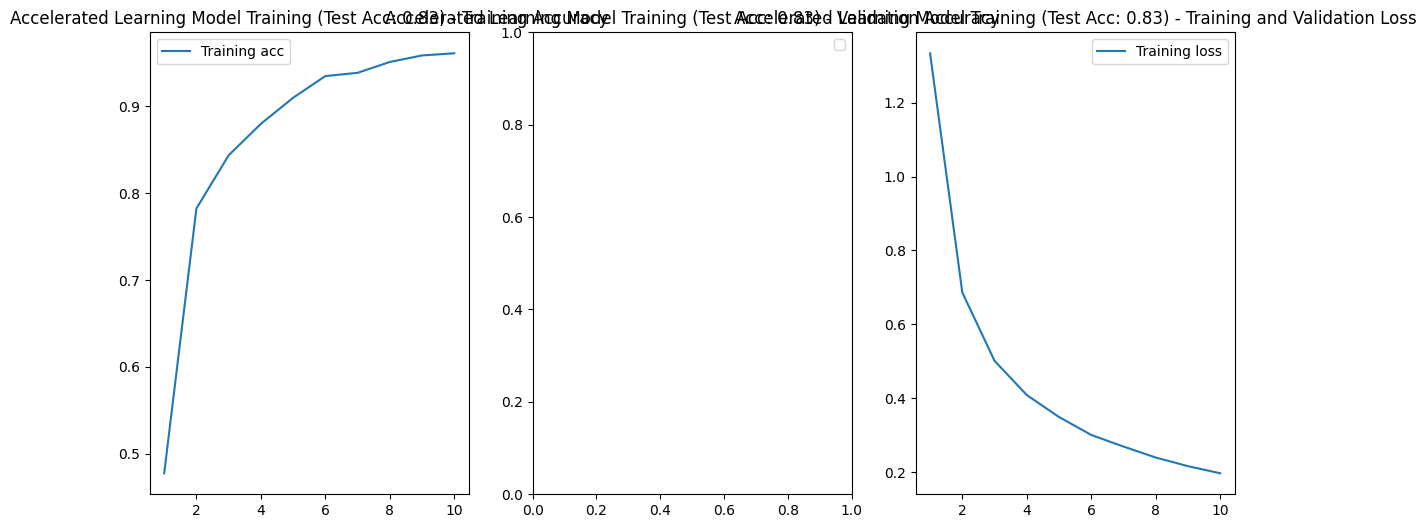

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3046 - loss: 1.5101 
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8002 - loss: 0.7348
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8620 - loss: 0.5059
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8909 - loss: 0.4117
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9050 - loss: 0.3495
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9099 - loss: 0.3246
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9324 - loss: 0.2811
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9364 - loss: 0.2553
Epoch 9/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9525 - loss: 0.2187
Epoch 10/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9614 - loss: 0.1869
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8747 - loss: 0.3966
7/7 ━━━━━

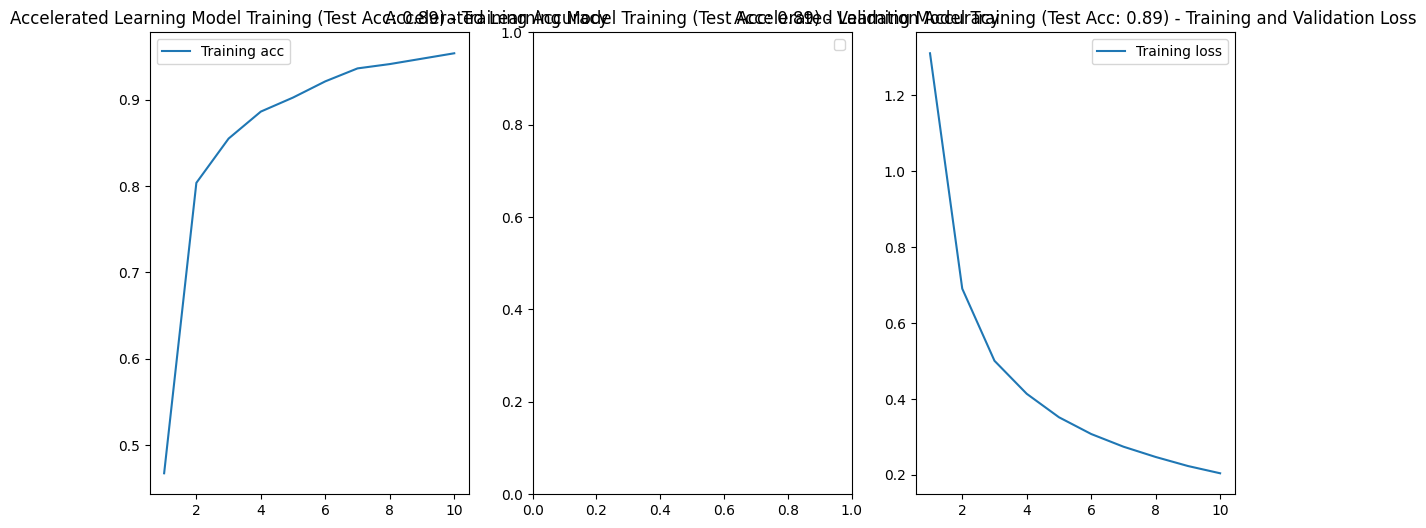

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3633 - loss: 1.5469 
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8039 - loss: 0.7155
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8434 - loss: 0.5189
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8684 - loss: 0.4418
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8964 - loss: 0.3510
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9333 - loss: 0.3074
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9439 - loss: 0.2670
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9516 - loss: 0.2380
Epoch 9/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9552 - loss: 0.2088
Epoch 10/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9665 - loss: 0.1942
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8393 - loss: 0.4500
7/7 ━━━━

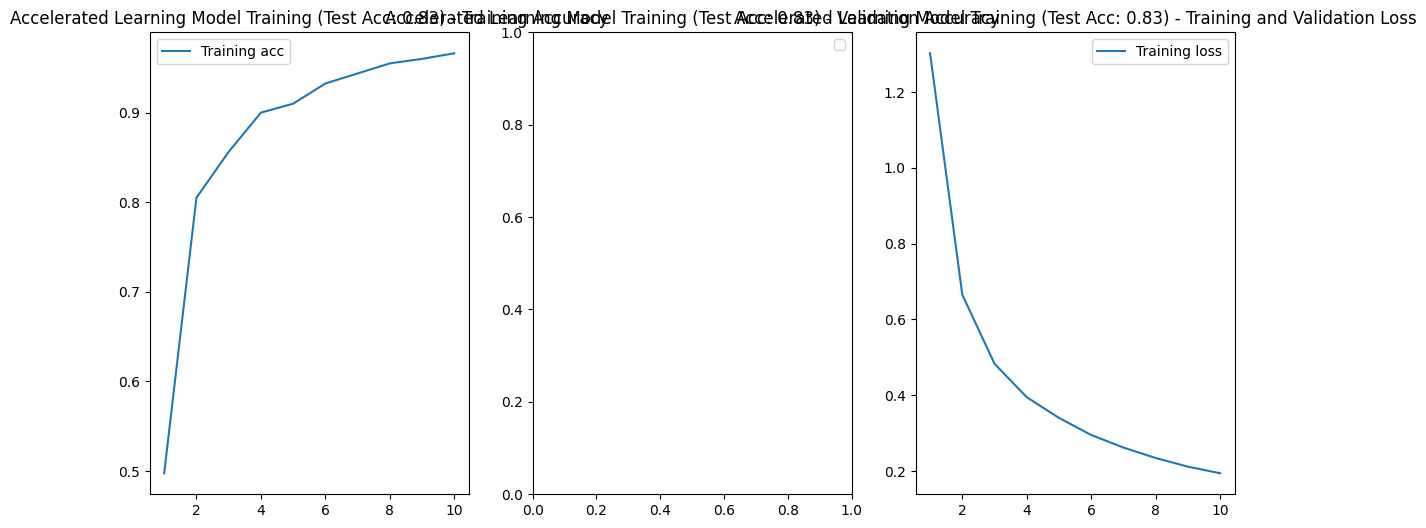

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3230 - loss: 1.5138 
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7789 - loss: 0.7097
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8074 - loss: 0.5368
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8876 - loss: 0.3896
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9166 - loss: 0.3502
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9285 - loss: 0.2970
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9465 - loss: 0.2709
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9493 - loss: 0.2493
Epoch 9/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9547 - loss: 0.2199
Epoch 10/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9690 - loss: 0.1862
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8373 - loss: 0.4150
7/7 ━━━━

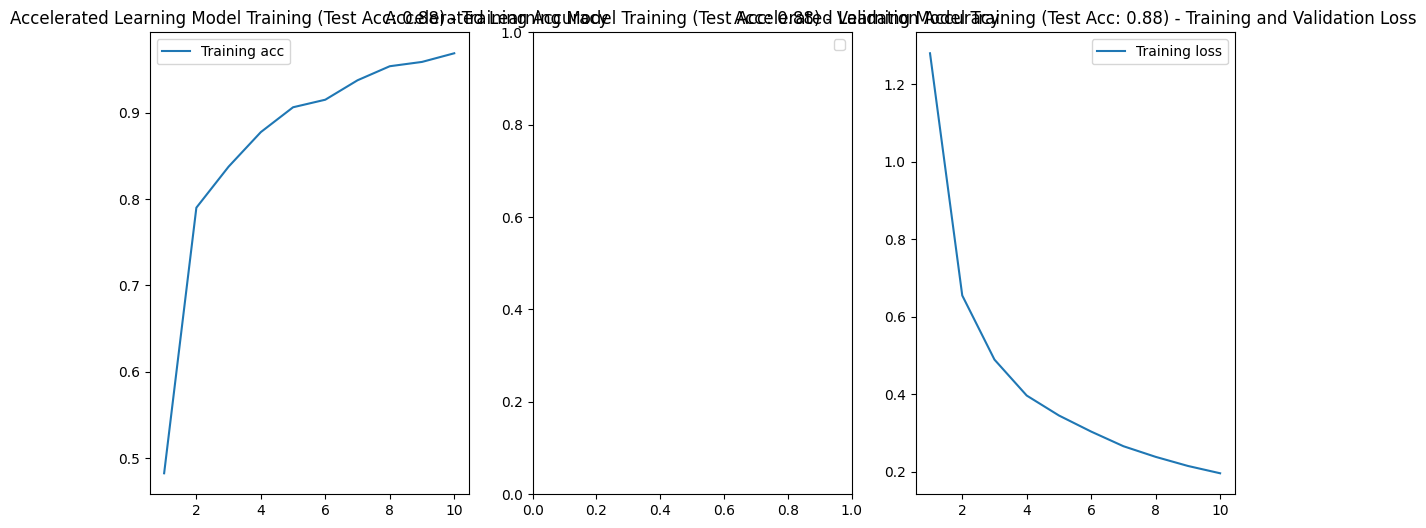

Accelerated Learning - Avg Metrics:
 [[0.90333767 0.89042208 0.82427705 0.86905778 0.80624993]
 [0.87955834 0.90174603 0.84923021 0.88869164 0.7718527 ]
 [0.89100639 0.89529628 0.83397097 0.87723254 0.78730277]]
Accelerated Learning - Sigma Metrics:
 [[0.03990833 0.02929684 0.06366841 0.05586664 0.1076516 ]
 [0.03006147 0.04248634 0.06515351 0.03333275 0.06898678]
 [0.03154141 0.02571643 0.04089445 0.02787979 0.08524505]]


In [9]:
if __name__ == "__main__":
    data_path = '/home/imhaom/CAB420_Machine_Learning/CAB320/small_flower_dataset'
    model = load_model()
    images, labels, class_names = load_data(data_path)
    (X_train, Y_train), (X_test, Y_test), (X_eval, Y_eval) = split_data(images, labels, train_fraction=0.8, randomize=True, eval_set=True)
    parameters = (0.001, 0.9, True)
    def print_class_distribution(labels, label_names):
        class_counts = np.sum(labels, axis=0)
        for name, count in zip(label_names, class_counts):
            print(f"{name}: {count}")
            
    # After loading and splitting the data
    print("Training class distribution:")
    print_class_distribution(Y_train, class_names)

    print("Testing class distribution:")
    print_class_distribution(Y_test, class_names)

    print("Validation class distribution:")
    print_class_distribution(Y_eval, class_names)
    # Transfer Learning
    trained_model_transfer, metrics_transfer = transfer_learning((X_train, Y_train), (X_eval, Y_eval), (X_test, Y_test), model, parameters, class_names)
    # trained_model_transfer.save("trained_model_transfer.h5")
    trained_model_transfer.summary()
    predictions_transfer = trained_model_transfer.predict(X_test)
    predicted_classes_transfer = np.argmax(predictions_transfer, axis=1)
    actual_classes_transfer = np.argmax(Y_test, axis=1)
    print("Transfer Learning Model Performance:", metrics_transfer)
    confusion_matrix(actual_classes_transfer, predicted_classes_transfer, class_names, plot=True)
    
    # Accelerated Learning
    trained_model_accelerated, metrics_accelerated = accelerated_learning((X_train, Y_train), (X_eval, Y_eval), (X_test, Y_test), model, parameters, class_names)
    # trained_model_accelerated.save("trained_model_accelerated.h5")
    trained_model_accelerated.summary()
    test_features_accelerated = model.predict(X_test)
    predictions_accelerated = trained_model_accelerated.predict(test_features_accelerated)
    predicted_classes_accelerated = np.argmax(predictions_accelerated, axis=1)
    actual_classes_accelerated = np.argmax(Y_test, axis=1)
    print("Accelerated Learning Model Performance:", metrics_accelerated)
    confusion_matrix(actual_classes_accelerated, predicted_classes_accelerated, class_names, plot=True)
    
    # K-Fold Validation for Transfer Learning
    avg_metrics_transfer, sigma_metrics_transfer = k_fold_validation(
        images, labels,
        lambda X_train, Y_train, X_test, Y_test: transfer_learning_classifier(
            X_train, Y_train, X_test, Y_test, model, parameters, class_names
        ),
        class_names, k=5
    )
    print("Transfer Learning - Avg Metrics:\n", avg_metrics_transfer)
    print("Transfer Learning - Sigma Metrics:\n", sigma_metrics_transfer)
    
    # K-Fold Validation for Accelerated Learning
    avg_metrics_accelerated, sigma_metrics_accelerated = k_fold_validation(
        images, labels,
        lambda X_train, Y_train, X_test, Y_test: accelerated_learning_classifier(
            X_train, Y_train, X_test, Y_test, model, parameters, class_names
        ),
        class_names, k=5
    )
    print("Accelerated Learning - Avg Metrics:\n", avg_metrics_accelerated)
    print("Accelerated Learning - Sigma Metrics:\n", sigma_metrics_accelerated)
